# 01 - Data exploration (Phase 1)

This notebook reads the two tables built by `python -m backend.preprocessing.ingest`:

* `neurons.parquet` - one row per neuron (future **graph nodes**)
* `edges.parquet` - one row per directed neuron pair (future **graph edges**)

Nothing here changes the data; it only shows what the pipeline produced and why.

In [1]:
import json
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl

from backend.preprocessing.loaders import load_neurons, scan_edges
from backend.utils.config import PROCESSED_DIR

report = json.loads((PROCESSED_DIR / 'ingest_report.json').read_text())
print('source      :', report['source'])
print('coordinates :', report['coordinates'])

source      : public
coordinates : pos_* and soma_* are FAFB voxels (4x4x40 nm), converted to nm


## 1. Neuron table: one row per node

In [2]:
neurons = load_neurons()
print(neurons.shape)
neurons.head(3)

(139262, 22)


node_index,neuron_id,x,y,z,soma_x,soma_y,soma_z,flow,super_class,cell_class,cell_sub_class,cell_type,hemibrain_type,side,neurotransmitter,nt_confidence,has_annotation,has_position,has_soma,has_connections,is_outlier
u32,i64,f32,f32,f32,f32,f32,f32,str,str,str,str,str,str,str,str,f32,bool,bool,bool,bool,bool
0,720575940596125868,710944.0,262716.0,205680.0,724212.0,275532.0,243080.0,"""intrinsic""","""optic""","""LO>LOP""","""unknown""","""T5c""","""unknown""","""right""","""acetylcholine""",0.590985,true,true,true,true,false
1,720575940597856265,808724.0,349448.0,203080.0,834880.0,354656.0,193640.0,"""intrinsic""","""optic""","""ME>LO""","""unknown""","""Tm16""","""unknown""","""right""","""acetylcholine""",0.836335,true,true,true,true,false
2,720575940597944841,754392.0,331248.0,183360.0,829856.0,375008.0,165040.0,"""intrinsic""","""optic""","""ME>LO""","""unknown""","""Tm7""","""unknown""","""right""","""acetylcholine""",0.786729,true,true,true,true,false


In [3]:
dict(neurons.schema)

{'node_index': UInt32,
 'neuron_id': Int64,
 'x': Float32,
 'y': Float32,
 'z': Float32,
 'soma_x': Float32,
 'soma_y': Float32,
 'soma_z': Float32,
 'flow': String,
 'super_class': String,
 'cell_class': String,
 'cell_sub_class': String,
 'cell_type': String,
 'hemibrain_type': String,
 'side': String,
 'neurotransmitter': String,
 'nt_confidence': Float32,
 'has_annotation': Boolean,
 'has_position': Boolean,
 'has_soma': Boolean,
 'has_connections': Boolean,
 'is_outlier': Boolean}

## 2. Why neuron IDs must stay `Int64`

FlyWire IDs have 18 digits. A `float64` can store every integer exactly only up to 2^53 (about 9 x 10^15). Larger integers get rounded, so two different neurons could end up with the same ID. pandas silently turns an integer column into `float64` as soon as one value is missing, which is why the pipeline keeps IDs as `Int64` and never lets them pass through floats.

In [4]:
ids = neurons['neuron_id'].to_list()
neuron_id = next(i for i in ids if int(float(i)) != i)
print('2**53              :', 2**53)
print('real neuron id     :', neuron_id)
print('after float64      :', int(np.float64(neuron_id)))

s = pd.Series([neuron_id, None])
print('pandas dtype with a missing value:', s.dtype, '-> still exact?', int(s[0]) == neuron_id)

2**53              : 9007199254740992
real neuron id     : 720575940596125868
after float64      : 720575940596125824
pandas dtype with a missing value: float64 -> still exact? False


## 3. Classification and missing values

In [5]:
neurons.group_by('super_class').len().sort('len', descending=True)

super_class,len
str,u32
"""optic""",77541
"""central""",32383
"""sensory""",16907
"""visual_projection""",8038
"""ascending""",1750
…,…
"""sensory_ascending""",612
"""visual_centrifugal""",524
"""motor""",110


In [6]:
neurons.group_by('neurotransmitter').len().sort('len', descending=True)

neurotransmitter,len
str,u32
"""acetylcholine""",86193
"""glutamate""",24875
"""gaba""",19171
"""dopamine""",5909
"""serotonin""",2282
"""unknown""",616
"""octopamine""",216


In [7]:
missing = pd.Series(report['neurons']['missing_values_before_fill'], name='missing before fill')
missing.to_frame().assign(percent=lambda d: (100 * d.iloc[:, 0] / len(neurons)).round(2))

,missing before fill,percent
x,14,0.01
y,14,0.01
z,14,0.01
soma_x,21158,15.19
soma_y,21158,15.19
soma_z,21158,15.19
flow,14,0.01
super_class,14,0.01
cell_class,31744,22.79
cell_sub_class,113434,81.45


## 4. Edge table: synapse counts

Only the `synapse_count` column is read here, not the whole 15-million-row table.

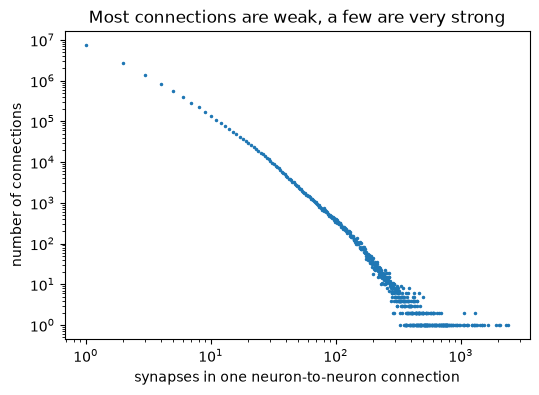

,edges kept
min synapses,
1,15091983
2,7595967
3,4916231
5,2700513
10,1066822
20,366864


In [8]:
counts = scan_edges().select('synapse_count').collect()['synapse_count'].to_numpy()
values, frequency = np.unique(counts, return_counts=True)

fig, ax = plt.subplots(figsize=(6, 4))
ax.loglog(values, frequency, '.', markersize=3)
ax.set_xlabel('synapses in one neuron-to-neuron connection')
ax.set_ylabel('number of connections')
ax.set_title('Most connections are weak, a few are very strong')
plt.show()

pd.Series(report['edges']['edges_with_min_synapses'], name='edges kept').rename_axis('min synapses').to_frame()

## 5. Edge weight = share of the target's input

`weight = synapse_count(A -> B) / total synapses received by B`. So for every target neuron, the weights of all its incoming edges add up to 1.

In [9]:
(
    scan_edges()
    .group_by('target_index')
    .agg(pl.col('weight').sum().alias('total_input_weight'))
    .select(pl.col('total_input_weight').min().alias('min'), pl.col('total_input_weight').max().alias('max'))
    .collect()
)

min,max
f32,f32
1.0,1.0


## 6. One neuron, end to end

In [10]:
example = neurons.filter(pl.col('cell_type') == 'DNa02').head(1)
if example.is_empty():
    example = neurons.filter(pl.col('super_class') == 'descending').head(1)
nid = example['neuron_id'].item()
example.select('neuron_id', 'cell_type', 'super_class', 'side', 'neurotransmitter', 'x', 'y', 'z')

neuron_id,cell_type,super_class,side,neurotransmitter,x,y,z
i64,str,str,str,str,f32,f32,f32
720575940604737708,"""DNa02""","""descending""","""right""","""acetylcholine""",612064.0,170248.0,83440.0


In [11]:
types = neurons.select('neuron_id', 'cell_type')
strongest_inputs = (
    scan_edges().filter(pl.col('target_id') == nid).collect()
    .join(types.rename({'neuron_id': 'source_id', 'cell_type': 'source_type'}), on='source_id')
    .sort('synapse_count', descending=True)
    .select('source_id', 'source_type', 'synapse_count', 'weight', 'sign')
)
print('incoming connections:', strongest_inputs.height)
strongest_inputs.head(5)

incoming connections: 751


source_id,source_type,synapse_count,weight,sign
i64,str,i32,f32,i8
720575940618058048,"""PS049""",378,0.028726,-1
720575940630085583,"""DNa03""",264,0.020062,1
720575940614403178,"""DNae005""",240,0.018238,1
720575940633556644,"""AOTU019""",216,0.016415,-1
720575940620686964,"""LAL018""",185,0.014059,1


In [12]:
strongest_outputs = (
    scan_edges().filter(pl.col('source_id') == nid).collect()
    .join(types.rename({'neuron_id': 'target_id', 'cell_type': 'target_type'}), on='target_id')
    .sort('synapse_count', descending=True)
    .select('target_id', 'target_type', 'synapse_count', 'weight', 'sign')
)
print('outgoing connections:', strongest_outputs.height)
strongest_outputs.head(5)

outgoing connections: 213


target_id,target_type,synapse_count,weight,sign
i64,str,i32,f32,i8
720575940624447240,"""PS137""",48,0.021343,1
720575940620746478,"""PS100""",39,0.004908,1
720575940622859021,"""PS137""",39,0.016854,1
720575940638989894,"""DNge026""",39,0.015707,1
720575940623992317,"""PS274""",35,0.006922,1


## 7. Where the neurons are (top view)

`x` and `y` are in nanometres; dividing by 1000 gives micrometres. The two big lobes on the sides are the optic lobes.

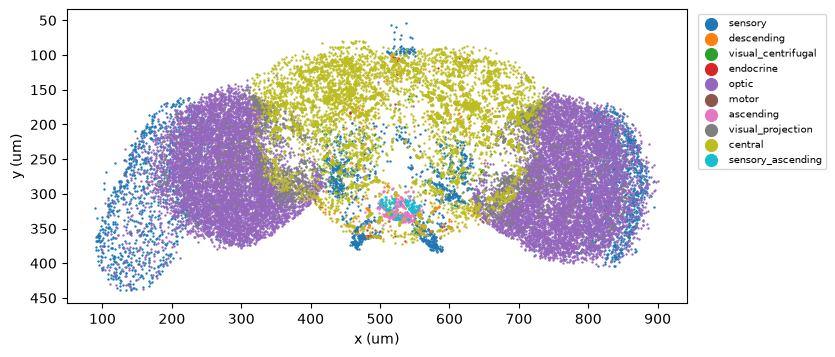

In [13]:
sample = neurons.filter(pl.col('has_position')).sample(30_000, seed=0)
fig, ax = plt.subplots(figsize=(8, 4.5))
for name, group in sample.group_by('super_class'):
    ax.scatter(group['x'] / 1000, group['y'] / 1000, s=0.5, label=name[0])
ax.invert_yaxis()  # image coordinates: y grows downwards
ax.set_aspect('equal')
ax.set_xlabel('x (um)')
ax.set_ylabel('y (um)')
ax.legend(markerscale=12, fontsize=7, bbox_to_anchor=(1.01, 1), loc='upper left')
plt.show()